In [1]:
####################################
#ENVIRONMENT SETUP

In [2]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import pandas as pd
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import h5py
import pickle 

#loading bar
from tqdm import tqdm

#dates
from datetime import datetime

In [3]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis","MPAS_Model_Data"))
from CLASSES_Directories import DirectoryManager_Class

In [4]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "MPAS_Model_Data", "LargeScale_Comparison")
dataType = "SurfaceAnalysis_ERA5_Model_Comparison"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/MPAS_Model_Data/RainfallHistogram



In [5]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [6]:
def GetSimulationTime(RunType):
    if (RunType[0] == "TRACER") and (RunType[1] == "MOIST"):
        SimulationTime = ("2022-06-30","2022-07-03")
    return SimulationTime

RunType = ("TRACER","MOIST","NSSL")
SimulationTime = GetSimulationTime(RunType)
ModelData_NSSL = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, SimulationTime)

RunType = ("TRACER","MOIST","TEMPO")
SimulationTime = GetSimulationTime(RunType)
ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, SimulationTime)

Found 289/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/history_cartesian/history.2022-06-30_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/diag_cartesian/diag.2022-06-30_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           MOIST
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-06-30 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:289
 # Diag Files:   289
 # Time Steps:   289
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL
 Static File:    TRACER_regional5250_scaled3_x20.835586.static.latlon.nc

Found 289/289 files matchi

In [ ]:
####################################
#CALCULATION FUNCTIONS

In [93]:
def GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName):
    """
    Retrieves a variable subset from the given model data.
    If varName contains a '+', returns the sum of the two variables.
    """
    if '+' in varName:
        var1, var2 = varName.split('+')
        var1 = var1.strip()
        var2 = var2.strip()

        subset1 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var1)
        subset2 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var2)
        variableSubset = subset1 + subset2
    else:
        variableSubset = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                             dataSubset_diag, dataSubset_static, varName)

    return variableSubset

def RunCalculations(ModelData, varNames):
    outputDictionary={}
    
    t = ModelData.Ntime-1
        
    #Loading Data
    [dataSubset, dataSubset_diag, dataSubset_static, lat, lon, _, _] = DataOperator_Class.GetData_Subset(ModelData, t)

    for varName in varNames:
        if count == 0: print(f"Running for {varName}")
        #Subsetting Data

        variableSubset= GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName)
        
    return variableSubset.data, variableSubset['latitude'], variableSubset['longitude']

In [94]:
####################################
#CALCULATION

In [95]:
rain_NSSL, lat,lon = RunCalculations(ModelData=ModelData_NSSL,varNames=['rainnc+rainc'])
rain_TEMPO, _,_ = RunCalculations(ModelData=ModelData_TEMPO,varNames=['rainnc+rainc'])

Running for rainnc+rainc
Running for rainnc+rainc


In [80]:
####################################
#PLOTTING FUNCTIONS

In [113]:
def CreateFigure_2x2(figsize=(10, 10),
                     wspace=0.3, hspace=0.3,
                     left=0.05, right=0.95, top=0.92, bottom=0.08):
    """
    Creates a 2x2 grid of subplots with adjustable layout.
    Returns (fig, axes) where axes is a 2D list [[ax00, ax01], [ax10, ax11]].
    """
    fig = plt.figure(figsize=figsize)
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom,
                        wspace=wspace, hspace=hspace)

    gs = gridspec.GridSpec(2, 2, figure=fig)

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])
    ax10 = fig.add_subplot(gs[1, 0])
    ax11 = fig.add_subplot(gs[1, 1])

    axes = [[ax00, ax01],
            [ax10, ax11]]

    return fig, axes

In [114]:
####################################
#PLOTTING

Text(0, 0.5, 'count')

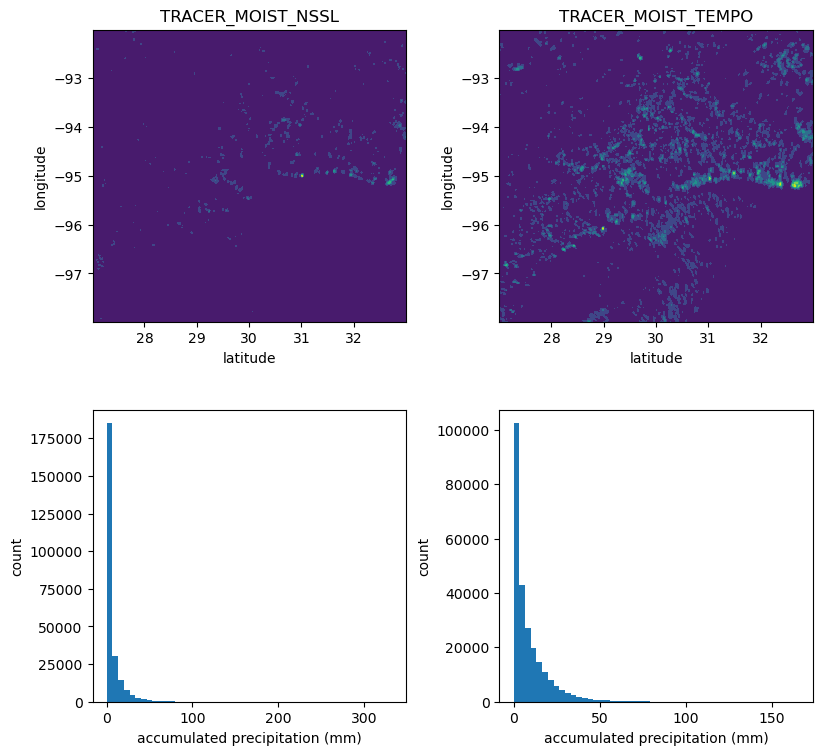

In [115]:
fig, axes = CreateFigure_2x2(figsize=(8,8))

#contour plot
axis = axes[0][0]
axis.contourf(lat,lon,rain_NSSL)
axis.set_xlabel('latitude'); axis.set_ylabel('longitude')
axis.set_title(f'{ModelData_NSSL.region}_{ModelData_NSSL.case}_{ModelData_NSSL.mpType}')

axis = axes[0][1]
axis.contourf(lat,lon,rain_TEMPO)
axis.set_xlabel('latitude'); axis.set_ylabel('longitude')
axis.set_title(f'{ModelData_TEMPO.region}_{ModelData_TEMPO.case}_{ModelData_TEMPO.mpType}')

#histograms
axis = axes[1][0]
axis.hist(rain_NSSL.flatten(),bins=50)
axis.set_xlabel('accumulated precipitation (mm)'); axis.set_ylabel('count')
axis = axes[1][1]
axis.hist(rain_TEMPO.flatten(),bins=50);
axis.set_xlabel('accumulated precipitation (mm)'); axis.set_ylabel('count')